# sfig7 — Deployment Scenario Grid (Supplementary Fig. S-7)

For a given **recording budget** (columns) and **required AUROC** (rows):
best achievable AUROC and the optimal (L, K) configuration per task.

Green = target met; red = not met.

**Data**: `heatmap_df_test.csv` per task, Transformer head.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
from pathlib import Path

# ── Workspace root ────────────────────────────────────────────────────────────
def _find_workspace():
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Main utils (TBME style, data, panels)
_nb_dir = PAPER_FIGURES / "notebooks"
sys.path.insert(0, str(_nb_dir))
# Explore utils (panel functions not yet ported to main panels.py)
_explore_nb_dir = PAPER_FIGURES / "explore" / "notebooks"
sys.path.insert(0, str(_explore_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS,
    TASK_LABEL, FONT_BASE, FONT_LABEL, CTX_ORDER,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels
from utils import panels_explore as xp   # panel functions not yet in panels.py

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
TASKS   = MAIN_TASKS
HEAD    = "transformer"
BUDGETS = [30, 60, 120, 240, 480]     # total signal minutes
TARGETS = [0.70, 0.75, 0.80, 0.85]   # required AUROC

hmaps = {t: load_heatmap("phase0_v3", t, HEAD) for t in TASKS}
print("Heatmap sizes:", {t: len(v) for t, v in hmaps.items()})

Heatmap sizes: {'sex_binary': 76, 'bmi_binary': 81, 'age_class': 81, 'sleep_efficiency_binary': 85, 'apnea_binary': 81}


/var/folders/_j/pvy19dq529559q352v51y7_00000gn/T/ipykernel_11145/4106179986.py:20: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.tight_layout(h_pad=1.5, w_pad=1.2)
/Users/boshra/NSRR-workspace/NSRR-tools/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


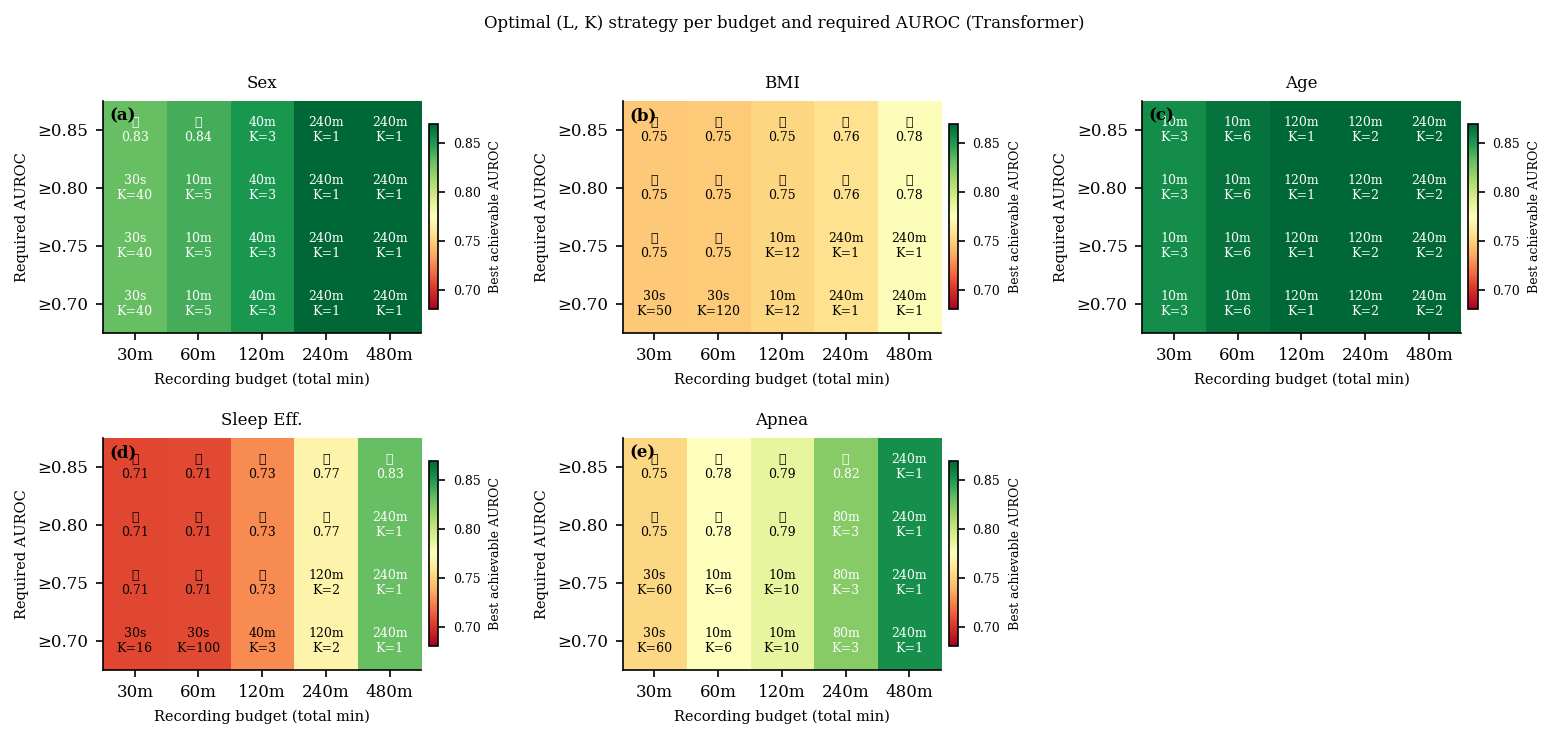

In [7]:
N_COLS = 3
N_ROWS = (len(TASKS) + N_COLS - 1) // N_COLS
ROW_H  = 2.4

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(7.0*1.5, N_ROWS * ROW_H))
axes_flat = axes.flatten()

for i, (ax, task) in enumerate(zip(axes_flat, TASKS)):
    xp.deployment_scenario_panel(ax, hmaps[task], task,
                                  budgets_min=BUDGETS, targets=TARGETS)
    ax.set_title(TASK_LABEL.get(task, task), fontsize=8)
    ax.text(0.02, 0.97, f"({chr(97+i)})", transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top")

for ax in axes_flat[len(TASKS):]:
    ax.set_visible(False)

fig.suptitle("Optimal (L, K) strategy per budget and required AUROC (Transformer)",
             fontsize=8, y=1.01)
fig.tight_layout(h_pad=1.5, w_pad=1.2)
plt.show()

In [ ]:
# ── Run when figure looks good ────────────────────────────────────────────────
save_figure(fig, FINAL_OUT, "sfig7_deployment_grid")
import shutil
shutil.copy(FINAL_OUT / "sfig7_deployment_grid.pdf",
            WORKSPACE_ROOT / "TBME_submission" / "sfig7_deployment_grid.pdf")
print("Saved + copied → TBME_submission/sfig7_deployment_grid.pdf")